#### **Fine-tuning Xception for CIFAR-10 classification**
This experiment fine-tunes the pretrained Xception model on a subset of the CIFAR-10 dataset to evaluate transfer learning performance, visualize predictions, and analyze class-wise accuracy and confusion patterns.

In [27]:
# import required libraries
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras import layers, Model, optimizers, callbacks
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

**Model selection**
- Using Xception model for model selection
- Xception model has better top-1 accuracy even though it has slightly lower number of parametres and size is lower too

**Step-1 : Load and prepare subset of CIFAR-10 dataset**

In [10]:
# load the data
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# labels for CIFAR-10
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = len(labels)

print(f"Training data shape: {x_train_full.shape}, Training labels shape: {y_train_full.shape}")

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)


C:\Users\santo\AppData\Local\Temp\ipykernel_47528\4165551003.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(labels[int(y_train_full[idx])], fontsize=8)


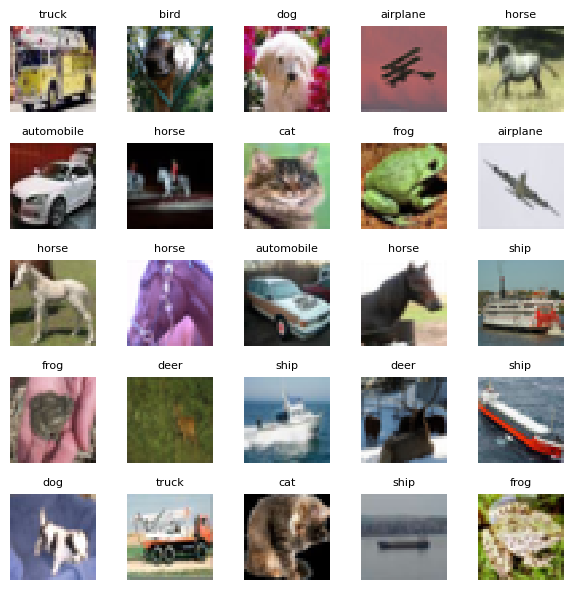

In [11]:
# randomly choose 25 unique indices from the training set
indices = np.random.choice(len(x_train_full), 25, replace=False)

# plot images
plt.figure(figsize=(6, 6))  # smaller figsize = sharper display
for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_full[idx].astype("uint8"), interpolation='nearest')
    plt.title(labels[int(y_train_full[idx])], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# training size = 1000, validation size = 200
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, train_size=1000, test_size=200, stratify=y_train_full, random_state=42
)

# test size = 200
_, x_test, _, y_test = train_test_split(
    x_test_full, y_test_full, test_size=200, stratify=y_test_full, random_state=42
)

In [13]:
# convert train, test, and validation labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, len(labels))
y_val = tf.keras.utils.to_categorical(y_val, len(labels))
y_test = tf.keras.utils.to_categorical(y_test, len(labels))

**Step-2 : Preprocess data for Xception model**

In [21]:
# define variables for image size, random seed, and batch size
IMG_SIZE = (299, 299) # Xception input size
RANDOM_SEED = 42
BATCH_SIZE = 16
DROPOUT_RATE = 0.5

In [15]:
def preprocess(image, label):
    '''Preprocess the image for Xception model'''

    image = tf.cast(image, tf.float32) # convert to float32
    image = tf.image.resize(image, IMG_SIZE) # resize to target size
    image = preprocess_xception(image)  # proper normalization for Xception
    
    return image, label

In [16]:
# prepare tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000, seed=RANDOM_SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

**Step-3 : Load pretrained exception model**

In [17]:
# include_top=False removes the classification head
base_model = Xception(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # start with frozen convolutional base

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Step-4 : Build the model**

In [18]:
# input layer
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

In [19]:
# augmentation layer
model_layers = inputs

# add data augementation layers which contains random flip, rotation, zoom, and contrast
model_layers = layers.RandomFlip("horizontal")(model_layers)
model_layers = layers.RandomRotation(0.1)(model_layers)
model_layers = layers.RandomZoom(0.2)(model_layers)
model_layers = layers.RandomContrast(0.2)(model_layers)

In [20]:
# feature extraction base model
model_layers = base_model(model_layers, training=False)

In [22]:
# custom classification head
model_layers = layers.GlobalAveragePooling2D()(model_layers) # global average pooling
model_layers = layers.Dense(512, activation='relu')(model_layers) # dense layer 1
model_layers = layers.Dropout(DROPOUT_RATE)(model_layers) # dropout for regularization
model_layers = layers.Dense(256, activation='relu')(model_layers) # dense layer 2
model_layers = layers.BatchNormalization()(model_layers) # batch normalization

outputs = layers.Dense(num_classes, activation='softmax')(model_layers) # output layer

In [23]:
# model assembly
model = Model(inputs, outputs)

**Step-5 : Compile the model**

In [24]:
# optimizer
LEARNING_RATE = 0.001 # low learning rate for fine-tuning
optimizer = optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.9)

# compile the model
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 299, 299, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 299, 299, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,045,490 (84.10 MB)

 Trainable params: 1,183,498 (4.51 MB)

 Non-trainable params: 20,861,992 (79.58 MB)

**Step-6 : Build the model**

In [25]:
# early stopping and learning rate reduction callbacks
earlystop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

In [28]:
start_time = time.time()
INITIAL_EPOCHS = 10
history_frozen = model.fit(train_ds, epochs=INITIAL_EPOCHS,
                           validation_data=val_ds,
                           callbacks=[earlystop, reduce_lr],
                           verbose=2)
frozen_train_time = time.time() - start_time
print(f"Base training time: {frozen_train_time:.1f}s")

Epoch 1/10
63/63 - 25s - 392ms/step - accuracy: 0.2050 - loss: 2.4690 - val_accuracy: 0.4300 - val_loss: 1.9465 - learning_rate: 1.0000e-03
Epoch 2/10
63/63 - 22s - 348ms/step - accuracy: 0.3830 - loss: 1.8104 - val_accuracy: 0.6450 - val_loss: 1.5881 - learning_rate: 1.0000e-03
Epoch 3/10
63/63 - 22s - 350ms/step - accuracy: 0.4470 - loss: 1.6330 - val_accuracy: 0.6950 - val_loss: 1.3071 - learning_rate: 1.0000e-03
Epoch 4/10
63/63 - 22s - 355ms/step - accuracy: 0.4930 - loss: 1.5033 - val_accuracy: 0.7350 - val_loss: 1.0785 - learning_rate: 1.0000e-03
Epoch 5/10
63/63 - 22s - 353ms/step - accuracy: 0.5150 - loss: 1.4429 - val_accuracy: 0.7650 - val_loss: 0.9111 - learning_rate: 1.0000e-03
Epoch 6/10
63/63 - 22s - 356ms/step - accuracy: 0.5370 - loss: 1.3436 - val_accuracy: 0.7450 - val_loss: 0.8462 - learning_rate: 1.0000e-03
Epoch 7/10
63/63 - 22s - 353ms/step - accuracy: 0.5260 - loss: 1.3491 - val_accuracy: 0.7450 - val_loss: 0.7692 - learning_rate: 1.0000e-03
Epoch 8/10
63/63 - 2

**Step-7 : Fine-Tuning**

In [29]:
base_model.trainable = True
UNFREEZE_LAST_N_LAYERS = 20
for layer in base_model.layers[:-UNFREEZE_LAST_N_LAYERS]:
    layer.trainable = False

In [31]:
# optimizer
LEARNING_RATE_FINE_TUNE = 1e-4
optimizer_finetune = optimizers.SGD(learning_rate=LEARNING_RATE_FINE_TUNE, momentum=0.9)

# compile the model
model.compile(optimizer=optimizer_finetune, loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
start_time = time.time()
FINE_TUNE_EPOCHS = 10
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS
history_fine = model.fit(train_ds,
                         epochs=TOTAL_EPOCHS,
                         initial_epoch=history_frozen.epoch[-1] + 1,
                         validation_data=val_ds,
                         callbacks=[earlystop, reduce_lr],
                         verbose=2)
fine_tune_time = time.time() - start_time
print(f"Fine-tuning time: {fine_tune_time:.1f}s")

Epoch 11/20
63/63 - 31s - 499ms/step - accuracy: 0.5240 - loss: 1.3925 - val_accuracy: 0.7700 - val_loss: 0.7851 - learning_rate: 1.0000e-04
Epoch 12/20
63/63 - 29s - 461ms/step - accuracy: 0.5340 - loss: 1.3093 - val_accuracy: 0.7450 - val_loss: 0.8004 - learning_rate: 1.0000e-04
Epoch 13/20

Epoch 13: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
63/63 - 28s - 437ms/step - accuracy: 0.5570 - loss: 1.3033 - val_accuracy: 0.7450 - val_loss: 0.8057 - learning_rate: 1.0000e-04
Epoch 14/20
63/63 - 28s - 444ms/step - accuracy: 0.5600 - loss: 1.2837 - val_accuracy: 0.7450 - val_loss: 0.8076 - learning_rate: 2.0000e-05
Epoch 15/20
63/63 - 28s - 444ms/step - accuracy: 0.5750 - loss: 1.2386 - val_accuracy: 0.7450 - val_loss: 0.8103 - learning_rate: 2.0000e-05
Fine-tuning time: 144.0s


**Step-8 : Evaluate**

In [33]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

13/13 - 4s - 278ms/step - accuracy: 0.6950 - loss: 0.9223

Test Accuracy: 0.6950 | Test Loss: 0.9223


**Interpretation**
- 69.5% accuracy on 200 image test subset is good the sample size is only 1000.
- The Xception model was pre-trained on natural images very different from CIFAR-10 and training was for only few epochs.

**Step-9 : Classification report and confusion matrix**

In [34]:
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    preds = model.predict(imgs)
    y_true.extend(np.argmax(lbls, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.40      0.53        20
  automobile       0.88      0.75      0.81        20
        bird       0.75      0.60      0.67        20
         cat       0.55      0.60      0.57        20
        deer       0.57      0.85      0.68        20
         dog       0.52      0.65      0.58        20
        frog       0.90      0.45      0.60        20
       horse       0.89      0.80   

**INterpretation**
- The airplpane class is often confused with "ship" and "truck" as they have similar textures.
- "Automobile" class is best performed.
- Cats and dogs are often confused even with large datasets, also "bird" is being confused with "cat".
- Deer have high recall and frog has high precision.
- Overall, the macro average values are 0.73 precision, 0.69 recall and 0.69 F1 which shows that the generalization is balanced and no extreme class bias.

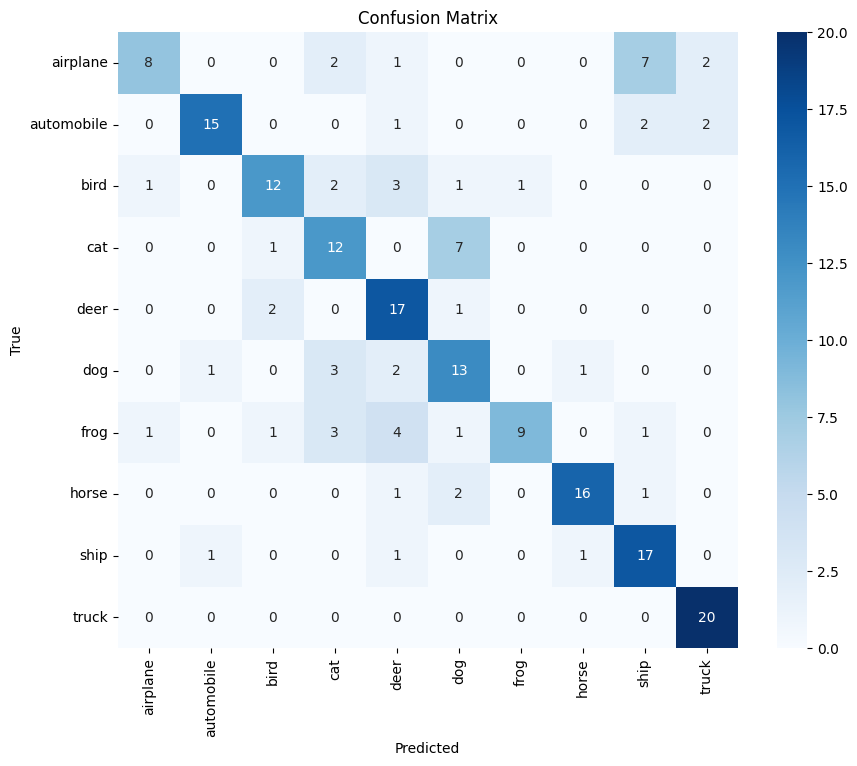

In [35]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**Interpretation**
- Most of the predictions lie along the diagonal which is good.
- The values which are off-diagnonal are 
    - Airplane with Ship/Truck as both have similar structural patterns.
    - Cat with Dog/Frog overlapping fur/texture cues.
    - Frog with Bird/Cat likely small animals with similar colors or environments.
- The model learns high-level object structure but struggles with fine-grained differences between visually similar classes

**Step-10 : Training curves**

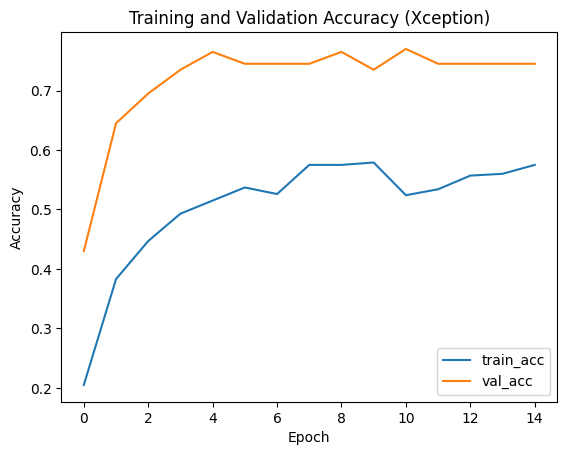

In [36]:
plt.plot(history_frozen.history['accuracy'] + history_fine.history['accuracy'], label='train_acc')
plt.plot(history_frozen.history['val_accuracy'] + history_fine.history['val_accuracy'], label='val_acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Xception)")
plt.legend()
plt.show()

**Interpretation**
- Train accuracy gradually rises to ~0.55–0.60
- Validation accuracy peaks early around 0.75, then slightly fluctuates
- This demonstrates that pretrained backbone quickly learned transferable features, and the gap between training (~0.55) and validation (~0.75) means the base model is underfitting a bit.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


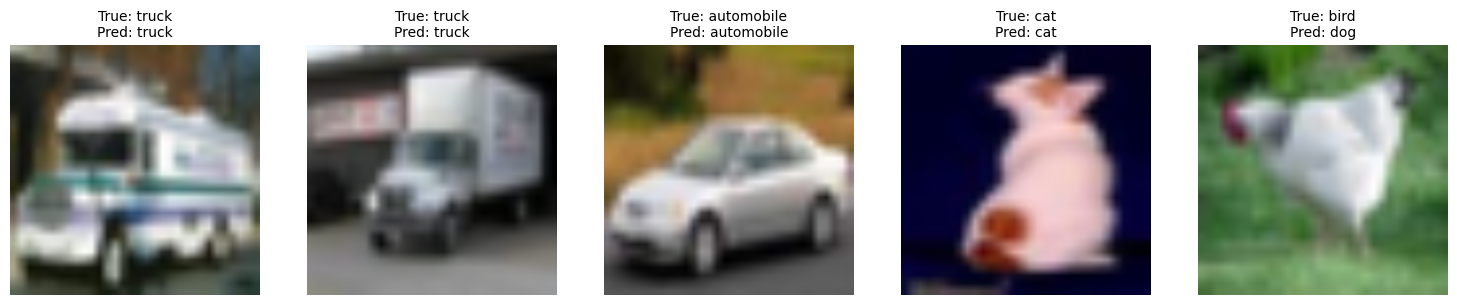

In [ ]:
# take one batch from the test dataset
images, true_lbls = next(iter(test_ds))

# get model predictions for first 5 images
preds = model.predict(images[:5])
pred_lbls = np.argmax(preds, axis=1)
true_lbls = np.argmax(true_lbls[:5], axis=1)

# plot the first 5 test images with predicted vs true labels
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    
    # convert image tensor to displayable format
    img = images[i].numpy()
    img = (img - img.min()) / (img.max() - img.min())  # normalize to [0, 1] for plotting
    
    plt.imshow(img)
    plt.title(f"True: {labels[true_lbls[i]]}\nPred: {labels[pred_lbls[i]]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()